<a href="https://colab.research.google.com/github/The-Professor99/ML_Practice/blob/main/hands_on_learning/hands_on_ml_with_scikit-learn_Aurelien_textbook/Chapter_6_Decision_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

In [ ]:
iris = load_iris()


In [ ]:
X = iris.data[:, 2:]
y = iris.target

In [ ]:
tree_clf = DecisionTreeClassifier(max_depth=2)

In [ ]:
tree_clf.fit(X, y)

DecisionTreeClassifier(max_depth=5, min_samples_split=50)

In [ ]:
from sklearn.tree import export_graphviz

In [ ]:
export_graphviz(tree_clf, \
               out_file="images/iris_tree.dot",
               feature_names=iris.feature_names[2:],
               class_names=iris.target_names,
               rounded=True,
               filled=True)

In [ ]:
!dot -Tpng images/iris_tree.dot -o images/iris_tree.png

In [ ]:
from matplotlib.colors import ListedColormap


In [ ]:
# def plot_decision_boundary(clf, X, y, axes=[0, 7.5, 0, 3], iris=True, legend=False, plot_training=True):
#     x1s = np.linspace(axes[0], axes[1], 100)
#     x2s = np.linspace(axes[2], axes[3], 100)
#     x1, x2 = meshgrid(x1s, x2s)
#     X_new = np.c_[x1.ravel(), x2.ravel()]
#     y_pred = clf.predict(X_new).reshape(x1.shape)

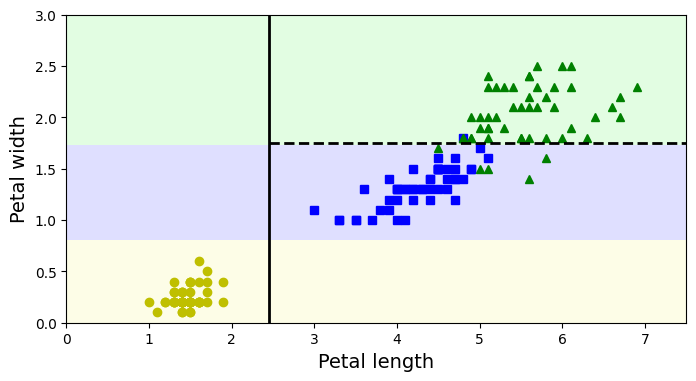

In [ ]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes=[0, 7.5, 0, 3], iris=True, legend=False, plot_training=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if not iris:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    if plot_training:
        plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris-Setosa")
        plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris-Versicolor")
        plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris-Virginica")
        plt.axis(axes)
    if iris:
        plt.xlabel("Petal length", fontsize=14)
        plt.ylabel("Petal width", fontsize=14)
    else:
        plt.xlabel(r"$x_1$", fontsize=18)
        plt.ylabel(r"$x_2$", fontsize=18, rotation=0)
    if legend:
        plt.legend(loc="lower right", fontsize=14)

plt.figure(figsize=(8, 4))
plot_decision_boundary(tree_clf, X, y)
# plt.plot([2.45, 2.45], [0, 3], "k-", linewidth=2)
# plt.plot([2.45, 7.5], [1.75, 1.75], "k--", linewidth=2)
# plt.plot([4.95, 4.95], [0, 1.75], "k:", linewidth=2)
# plt.plot([4.85, 4.85], [1.75, 3], "k:", linewidth=2)
# plt.text(1.40, 1.0, "Depth=0", fontsize=15)
# plt.text(3.2, 1.80, "Depth=1", fontsize=13)
# plt.text(4.05, 0.5, "(Depth=2)", fontsize=11)

# save_fig("decision_tree_decision_boundaries_plot")
# plt.show()

In [ ]:
def test_plot(X, y):
    plt.figure()
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris-Setosa")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris-Versicolor")
    plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris-Virginica")
    plt.xlabel("Petal length", fontsize=14)
    plt.ylabel("Petal width", fontsize=14)
#     plt.legend(loc="lower right", fontsize=14)
    plt.axis([0, 7.5, 0, 3])
    plt.plot([0, 7.5], [0.8, 0.8], "k-", linewidth=2)
    plt.plot([0, 7.5], [1.75, 1.75], "k--", linewidth=2)
    plt.plot([4.95, 4.95], [0, 1.75], "k:", linewidth=2)
    plt.plot([4.85, 4.85], [1.75, 3], "r:", linewidth=2)

# plt.plot([4.85, 4.85], [1.75, 3], "k:", linewidth=2)
# plt.text(1.40, 1.0, "Depth=0", fontsize=15)
# plt.text(3.2, 1.80, "Depth=1", fontsize=13)
# plt.text(4.05, 0.5, "(Depth=2)", fontsize=11)

In [ ]:
%matplotlib

Using matplotlib backend: TkAgg


In [ ]:

test_plot(X, y)

In [ ]:
tree_clf.predict_proba([[5, 1.5]])

array([[0.        , 0.90740741, 0.09259259]])

In [ ]:
tree_clf.predict([[5, 1.5]])

array([1])

In [ ]:
tree_clf.predict_proba([[6, 1.5]])

array([[0.        , 0.90740741, 0.09259259]])

### Regression

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
np.random.seed(42)
m = 200
X = np.random.rand(m, 1)
y = 4 * (X - 0.5) ** 2
y = y + np.random.randn(m, 1) / 10

In [ ]:
plt.plot(X, y, "b.")

In [ ]:
tree_reg = DecisionTreeRegressor(min_samples_split=30)
tree_reg.fit(X, y)

DecisionTreeRegressor(min_samples_split=30)

In [ ]:
export_graphviz(tree_reg, out_file="images/tree_reg.dot"
               )

In [ ]:
!dot -Tpng images/tree_reg.dot -o images/tree_reg.png

In [ ]:
def plot_regression_predictions(tree_reg, X, y, axes=[0, 1, -0.2, 1], ylabel="$y$"):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$", fontsize=18)
    if ylabel:
        plt.ylabel(ylabel, fontsize=18, rotation=0)
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")


In [ ]:
plot_regression_predictions(tree_reg, X, y)

In [ ]:
for split, style in ((0.197, "k-"), (0.092, "k--"), (0.772, "k--"), (0.287, "r--"), (0.904, "r-"), (0.628, "b--"), (0.422, "b-"),  (0.576, "g-")):
    plt.plot([split, split], [-0.2, 1], style, linewidth=2)
